# Cleaning and Exploratory Data Analysis

In [9]:
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Download hourly data from Kaggle and print data variables names 

In [10]:
# Download latest version
path = kagglehub.dataset_download("eugeniyosetrov/load-wind-and-solar-prices-in-hourly-resolution")
filename = "time_series_60min_singleindex.csv"
file_size = os.path.getsize(path)
print("Path to dataset files:", path)
print(f"File size: {file_size} bytes")

data = pd.read_csv(path + "/" +  filename)
print(data.columns)

Path to dataset files: /Users/b6072271/.cache/kagglehub/datasets/eugeniyosetrov/load-wind-and-solar-prices-in-hourly-resolution/versions/4
File size: 160 bytes
Index(['utc_timestamp', 'cet_cest_timestamp',
       'AT_load_actual_entsoe_transparency',
       'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead',
       'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       ...
       'SI_load_actual_entsoe_transparency',
       'SI_load_forecast_entsoe_transparency', 'SI_solar_generation_actual',
       'SI_wind_onshore_generation_actual',
       'SK_load_actual_entsoe_transparency',
       'SK_load_forecast_entsoe_transparency', 'SK_solar_generation_actual',
       'SK_wind_onshore_generation_actual',
       'UA_load_actual_entsoe_transparency',
       'UA_load_forecast_entsoe_transparency'],
      dtype='str', length=300)


Change the index of the whole datadframe to be the timestamps. 

In [11]:
data['GB_GBN_price_day_ahead']

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
         ...  
50396    46.55
50397    40.95
50398    34.84
50399    37.44
50400      NaN
Name: GB_GBN_price_day_ahead, Length: 50401, dtype: float64

In [12]:
data['utc_timestamp'] = pd.to_datetime(data['utc_timestamp'])
data = data.set_index('utc_timestamp').sort_index()
data = data.asfreq('h') 

Create a new dataframe, a subset of the oiriginal downloaded dataframe, which only has columns related to energy prices and usage in Great Britain.

In [13]:
uk_columns = [col for col in data.columns if 'UKM' in col]
data_uk = data[uk_columns]
print(data_uk.columns)

Index(['GB_UKM_load_actual_entsoe_transparency',
       'GB_UKM_load_forecast_entsoe_transparency', 'GB_UKM_solar_capacity',
       'GB_UKM_solar_generation_actual', 'GB_UKM_wind_capacity',
       'GB_UKM_wind_generation_actual', 'GB_UKM_wind_offshore_capacity',
       'GB_UKM_wind_offshore_generation_actual',
       'GB_UKM_wind_onshore_capacity',
       'GB_UKM_wind_onshore_generation_actual'],
      dtype='str')


In [14]:
gb_columns = [col for col in data.columns if 'GBN' in col]
data_gb = data[gb_columns]
print(data_gb.columns)

Index(['GB_GBN_load_actual_entsoe_transparency',
       'GB_GBN_load_forecast_entsoe_transparency', 'GB_GBN_price_day_ahead',
       'GB_GBN_solar_capacity', 'GB_GBN_solar_generation_actual',
       'GB_GBN_solar_profile', 'GB_GBN_wind_capacity',
       'GB_GBN_wind_generation_actual', 'GB_GBN_wind_profile',
       'GB_GBN_wind_offshore_capacity',
       'GB_GBN_wind_offshore_generation_actual',
       'GB_GBN_wind_offshore_profile', 'GB_GBN_wind_onshore_capacity',
       'GB_GBN_wind_onshore_generation_actual', 'GB_GBN_wind_onshore_profile'],
      dtype='str')


Inspect the dataset for missing values. Woah! A lot of missing values up in here. What are we going to do? Large number of mssing values in wind related measurements specifically. Let's see if there is a reason

In [15]:
print(data_gb.isna().sum().sort_values(ascending=False))
print('Total number of observations: ' + str(data_gb.shape[0]))


GB_GBN_solar_profile                        6649
GB_GBN_wind_profile                         6641
GB_GBN_wind_offshore_profile                6641
GB_GBN_wind_onshore_profile                 6641
GB_GBN_solar_capacity                       6600
GB_GBN_wind_capacity                        6600
GB_GBN_wind_offshore_capacity               6600
GB_GBN_wind_onshore_capacity                6600
GB_GBN_load_forecast_entsoe_transparency     121
GB_GBN_price_day_ahead                       111
GB_GBN_solar_generation_actual                55
GB_GBN_wind_generation_actual                 41
GB_GBN_wind_offshore_generation_actual        41
GB_GBN_wind_onshore_generation_actual         41
GB_GBN_load_actual_entsoe_transparency         7
dtype: int64
Total number of observations: 50401


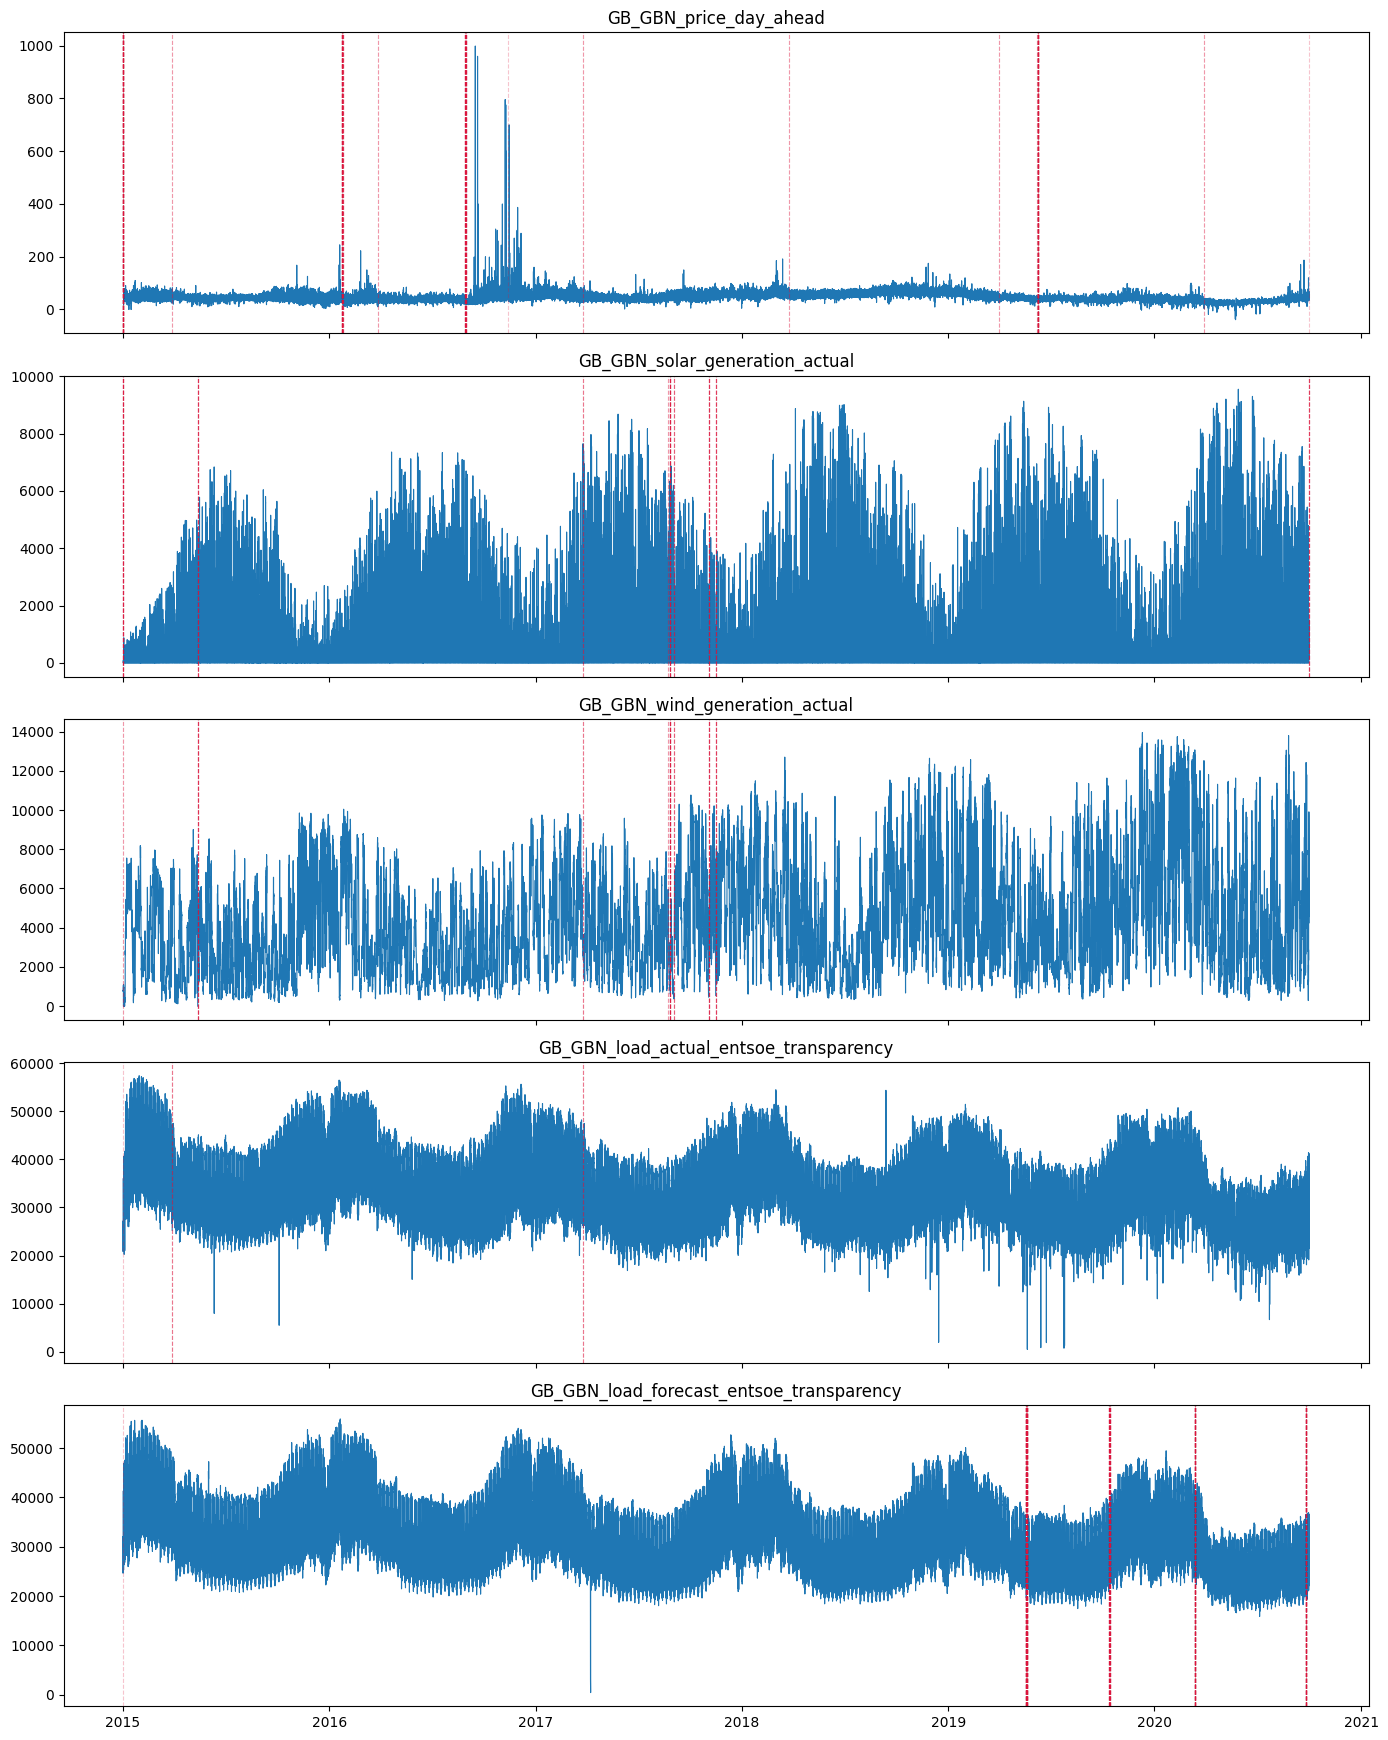

In [16]:
columns_of_interest = [
    "GB_GBN_price_day_ahead",
    "GB_GBN_solar_generation_actual",
    "GB_GBN_wind_generation_actual",
    "GB_GBN_load_actual_entsoe_transparency", 
    "GB_GBN_load_forecast_entsoe_transparency"
]

data_gb_energy = data_gb[columns_of_interest]

fig, axes = plt.subplots(data_gb_energy.shape[1], 1, figsize=(14, 3.5 * data_gb_energy.shape[1]), sharex=True)

if data_gb_energy.shape[1] == 1:
    axes = [axes]

for ax, column in zip(axes, columns_of_interest):
    series = data_gb_energy[column]
    ax.plot(series.index, series, linewidth=0.8, label=column)

    missing_times = series.index[series.isna()]
    for i, ts in enumerate(missing_times):
        ax.axvline(ts, color="crimson", linestyle="--", alpha=0.25, linewidth=0.8,
                   label="Missing value" if i == 0 else None)

    ax.set_title(column)
    # ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [17]:
print(data_gb[columns_of_interest].isna().sum())
print('Total number of observations: ' + str(data_gb.shape[0]))

GB_GBN_price_day_ahead                      111
GB_GBN_solar_generation_actual               55
GB_GBN_wind_generation_actual                41
GB_GBN_load_actual_entsoe_transparency        7
GB_GBN_load_forecast_entsoe_transparency    121
dtype: int64
Total number of observations: 50401


In the case of load forecating and day ahead prices there is relatively large number of missing values and the figure shows these are clustered to a few small times within the dataset. For what times are the missing values? Are these consecutive missing values and are they caused by a specific reason?

In [18]:
for col in data_gb_energy.columns:
    missing_idx = data_gb_energy.index[data_gb_energy[col].isna()]

    print (col)
    if len(missing_idx) == 0:
        print("No missing values")
    else:
        gaps = missing_idx.to_series()
        groups = (gaps.diff() != pd.Timedelta(hours=1)).cumsum()
        ranges = gaps.groupby(groups).agg(["min", "max"])
        print(ranges)
        
    print('\n')


GB_GBN_price_day_ahead
                                    min                       max
utc_timestamp                                                    
1             2014-12-31 23:00:00+00:00 2015-01-01 23:00:00+00:00
2             2015-03-29 02:00:00+00:00 2015-03-29 03:00:00+00:00
3             2016-01-23 23:00:00+00:00 2016-01-24 22:00:00+00:00
4             2016-03-27 02:00:00+00:00 2016-03-27 03:00:00+00:00
5             2016-08-28 22:00:00+00:00 2016-08-29 21:00:00+00:00
6             2016-11-11 23:00:00+00:00 2016-11-11 23:00:00+00:00
7             2017-03-26 02:00:00+00:00 2017-03-26 03:00:00+00:00
8             2018-03-25 02:00:00+00:00 2018-03-25 03:00:00+00:00
9             2019-03-31 02:00:00+00:00 2019-03-31 03:00:00+00:00
10            2019-06-07 22:00:00+00:00 2019-06-08 21:00:00+00:00
11            2020-03-29 02:00:00+00:00 2020-03-29 03:00:00+00:00
12            2020-09-30 23:00:00+00:00 2020-09-30 23:00:00+00:00


GB_GBN_solar_generation_actual
                    

The SARIMAX function automatically fits a Kalman filter to time series data with missing values. So, we can fit an ARIMA model and extract fitted values for the missing data. 

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    data_gb.GB_GBN_price_day_ahead,
    order=(2,1,0),           
    seasonal_order=(2, 0, 0, 24)
)

In [20]:
result = model.fit(disp=False)

In [21]:
fitted_values = result.fittedvalues

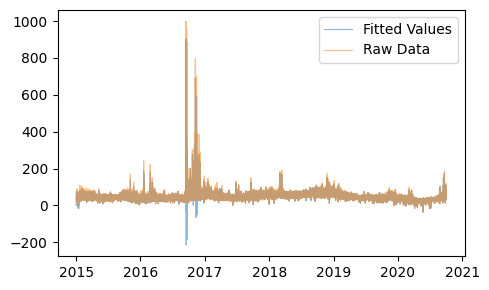

In [22]:
fitted_values

fig, axes = plt.subplots(1, 1, figsize=(5,3), sharex=False)

axes.plot(fitted_values.index, fitted_values, linewidth=0.8, label='Fitted Values', alpha=0.5)
axes.plot(data_gb_energy.index, data_gb_energy.GB_GBN_price_day_ahead, linewidth=0.8, label='Raw Data', alpha=0.5)
axes.legend()
plt.tight_layout()
plt.show()


In [23]:
fitted_values

utc_timestamp
2014-12-31 23:00:00+00:00     0.000000
2015-01-01 00:00:00+00:00     0.000000
2015-01-01 01:00:00+00:00     0.000000
2015-01-01 02:00:00+00:00     0.000000
2015-01-01 03:00:00+00:00     0.000000
                               ...    
2020-09-30 19:00:00+00:00    50.004772
2020-09-30 20:00:00+00:00    39.556915
2020-09-30 21:00:00+00:00    37.498560
2020-09-30 22:00:00+00:00    38.121072
2020-09-30 23:00:00+00:00    34.467675
Freq: h, Length: 50401, dtype: float64

In [24]:
data_gb_energy.GB_GBN_price_day_ahead

utc_timestamp
2014-12-31 23:00:00+00:00      NaN
2015-01-01 00:00:00+00:00      NaN
2015-01-01 01:00:00+00:00      NaN
2015-01-01 02:00:00+00:00      NaN
2015-01-01 03:00:00+00:00      NaN
                             ...  
2020-09-30 19:00:00+00:00    46.55
2020-09-30 20:00:00+00:00    40.95
2020-09-30 21:00:00+00:00    34.84
2020-09-30 22:00:00+00:00    37.44
2020-09-30 23:00:00+00:00      NaN
Freq: h, Name: GB_GBN_price_day_ahead, Length: 50401, dtype: float64

In [25]:
data_gb_energy.to_csv('../gb_energy_data.csv')